In JuMag, we can use Monte Carlo to compute the M-T curve.
For the atomistic model with $z$ nearest neighbors, the relation between exchange constant and $T_c$ reads [1]

$$
J = \frac{3 k_B T_c}{ \epsilon z }
$$

where $\epsilon$ is a correction factor. For 3D classical Heisenberg model $\epsilon \approx 0.719$.
In this example, we will assume $J=300k_B$ which gives $T_c = 431 K$. The full script is shown below.

In [1]:
using JuMag


JuMag.cuda_using_double(true)

function relax_system_single(T)
  mesh =  CubicMeshGPU(nx=30, ny=30, nz=30, pbc="xyz")
  sim = MonteCarlo(mesh, name="mc")
  init_m0(sim, (0,0,1))

  add_exch(sim, J=300*k_B)
  add_dmi(sim, D=0, D1=0)
  add_zeeman(sim, Hx=0, Hy=0, Hz=0)
  add_anis(sim, Ku=0, Kc=0)

  sim.T = 100000
  run_sim(sim, maxsteps=50000, save_vtk_every=-1, save_m_every=-1)
  sim.T = T
  run_sim(sim, maxsteps=200000, save_vtk_every=-1, save_m_every=-1)

  ms = zeros(1000)
  sim.T = T
  for i = 1:1000
      run_sim(sim, maxsteps=100, save_vtk_every=-1, save_m_every=-1)
      t = JuMag.average_m(sim)
      ms[i] = sqrt(t[1]^2+t[2]^2+t[3]^2)
  end
  return sum(ms)/length(ms)
end

function relax_system()
  f = open("assets/M_H.txt", "w")
  write(f, "#T(K)     m \n")
  for T = 10:20:500
      println("Running for $T ...")
      m = relax_system_single(T)
      write(f, "$T    $m \n")
  end
  close(f)
end

relax_system (generic function with 1 method)

Run the relax_system function.

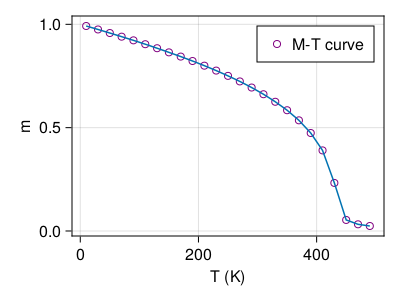

In [2]:
if filesize("assets/M_H.txt") == 0
  relax_system()
end


using DelimitedFiles
using CairoMakie

function plot_m_H()

  fig = Figure(resolution = (400, 300))
  ax = Axis(fig[1, 1],
      xlabel = "T (K)",
      ylabel = "m"
  )

  data = readdlm("assets/M_H.txt", skipstart=1)
  sc1 = scatter!(ax, data[:, 1], data[:, 2], markersize = 10, label="M-T curve")
  sc1.color = :transparent
  sc1.strokewidth = 1
  sc1.strokecolor = :purple
  lines!(ax, data[:, 1], data[:, 2])


  axislegend()

  #save("M_T.png", fig)

  return fig

end

plot_m_H()

[1] Atomistic spin model simulations of magnetic nanomaterials, J. Phys.: Condens. Matter 26 (2014) 103202.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*